In [14]:
import numpy as np
from tqdm.auto import tqdm

from utils.plot import *

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader

In [15]:
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print("Using PyTorch version: {}, Device: {}".format(torch.__version__, DEVICE))

Using PyTorch version: 1.7.1, Device: cuda


In [3]:
# ----- Utils -----

In [6]:
def train(model, train_loader, optimizer, scheduler = None):
    model.train()
    train_loss = 0
    correct = 0
    tqdm_bar = tqdm(enumerate(train_loader))
    for batch_idx, (image, label) in tqdm_bar:
        image = image.to(DEVICE)
        label = label.to(DEVICE)
        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        train_loss += loss.item()
        prediction = output.max(1, keepdim = True)[1]
        correct += prediction.eq(label.view_as(prediction)).sum().item()
        optimizer.step()
        tqdm_bar.set_description("Epoch {} - train loss: {:.6f}".format(epoch, loss.item()))
    if scheduler is not None:
        scheduler.step()
    train_loss /= len(train_loader.dataset)
    train_acc = 100. * correct / len(train_loader.dataset)
    return train_loss, train_acc

def evaluate(model, test_loader):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for image, label in tqdm(test_loader):
            image = image.to(DEVICE)
            label = label.to(DEVICE)
            output = model(image)
            test_loss += criterion(output, label).item()
            prediction = output.max(1, keepdim = True)[1]
            correct += prediction.eq(label.view_as(prediction)).sum().item()
    
    test_loss /= len(test_loader.dataset)
    test_acc = 100. * correct / len(test_loader.dataset)
    return test_loss, test_acc

In [5]:
# ----- Load Fashion MNIST -----

In [5]:
BATCH_SIZE = 1024

train_loader = DataLoader(datasets.FashionMNIST('./data/',
                          train=True, download=True,
                          transform=transforms.Compose([transforms.ToTensor(),
                                                        transforms.Normalize((0.1307,), (0.3081,))])), # train data에서 흑,백의 평균값이 0.1307, 0.3081 -> mean centered
                          batch_size=BATCH_SIZE, shuffle=True)

test_loader = DataLoader(datasets.FashionMNIST('./data/',
                          train=False,
                          transform=transforms.Compose([transforms.ToTensor(),
                                                        transforms.Normalize((0.1307,), (0.3081,))])),
                          batch_size=BATCH_SIZE, shuffle=True)

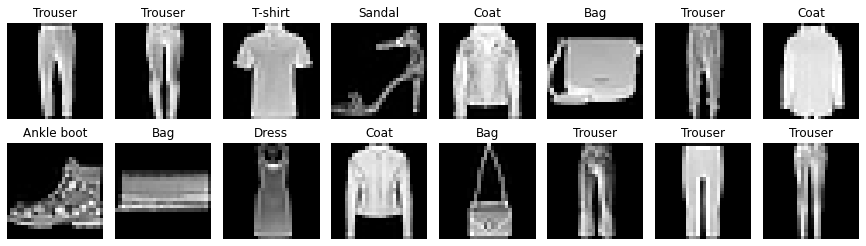

In [9]:
plot_dataset(train_loader)

In [8]:
# ----- Custom Dropout -----

In [9]:
# 1. numpy
w1 = np.array([[.2, -.5, .1, 2.],
              [1.5, 1.3, 2.1, 0.],
              [0., .25, .2, -.3]])
data = np.array([56, 231, 24, 2]).reshape(4, 1)
b1 = np.array([1.1, 3.2, -1.2]).reshape(3, 1)

w2 = np.array([.3, 1.5, -.5]).reshape(1, 3)
b2 = 0.8

p = 0.5

def train_step(data, p):
    h1 = np.maximum(0, np.dot(w1, data) + b1) 
    print(h1, 'h1')
    u1 = (np.random.rand(*h1.shape) < p) / p # h1의 값들 중 일부가 사라지므로 h2의 값이 전반적으로 줄어들텐데 이를 방지하기 위해 p로 나눠사 깂을 늘림
    print(u1, 'u1')
    h1 *= u1 # True이면 1을 곱하고 False이먄 0을 곱함으로써 dropout
    print(h1, 'h1')
    h2 = np.maximum(0, np.dot(w2, h1) + b2) # h1의 값들 중 일부가 사라지므로 h2의 값이 전반적으로 줄어들 것임
    print(h2, 'h2')
    u2 = (np.random.rand(*h2.shape) < p) / p
    print(u2, 'u2')
    h2 *= u2
    print(h2, 'h2')

def test_step(data):
    h1 = np.maximum(0, np.dot(w1, data) + b1) # test에서는 p와 무관하게 작동하도록 함
    print('h1', h1)
    h2 = np.maximum(0, np.dot(w2, h1) + b2) 
    print('h2', h2)
    
train_step(data, p)
test_step(data)

[[  0.  ]
 [437.9 ]
 [ 60.75]] h1
[[0.]
 [2.]
 [2.]] u1
[[  0. ]
 [875.8]
 [121.5]] h1
[[1253.75]] h2
[[2.]] u2
[[2507.5]] h2
h1 [[  0.  ]
 [437.9 ]
 [ 60.75]]
h2 [[627.275]]


In [10]:
# 2. pytorch
class Dropout(nn.Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()
        if p < 0 or p > 1:
            raise ValueError("dropout probability has to be between 0 and 1, "
                             "but got {}".format(p))
        self.p = p

    def forward(self, input):
        mask = (np.random.rand(*input.shape) < self.p) / self.p
        output = input * torch.Tensor(mask).to(DEVICE)
        return output.to(DEVICE)

    def __repr__(self):
        return self.__class__.__name__ + '(' + 'p=' + str(self.p) + ')'

In [11]:
# 예시로 확인
x = torch.rand((3, 2)).to(DEVICE)
Dropout(p=0.5)(x)

tensor([[0.0000, 0.0000],
        [0.0000, 0.0000],
        [1.6691, 0.0000]], device='cuda:0')

In [16]:
# dropout 하지 않는 경우
class SimpleClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)  
        
    def forward(self, x):
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.log_softmax(self.fc4(x), dim=1)
        return x

In [ ]:
EPOCHS = 20
model = SimpleClassifier().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train(model, train_loader, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tLR: {:.4f}, \tTrain Loss: {:.4f}, \tTrain Accuracy: {:.2f} %, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, optimizer.param_groups[0]['lr'], train_loss, train_accuracy, test_loss, test_accuracy))
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
plot_history(history)

In [ ]:
# dropout ratio를  0.3으로 하는 경우
class RegClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,64)
        self.fc4 = nn.Linear(64,10)
        self.dropout = Dropout(p=0.3)
    
    def forward(self,x):
        x = x.view(x.shape[0],-1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = F.log_softmax(self.fc4(x),dim=1)
        
        return x

In [ ]:
EPOCHS = 20
model = RegClassifier().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train(model, train_loader, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tLR: {:.4f}, \tTrain Loss: {:.4f}, \tTrain Accuracy: {:.2f} %, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, optimizer.param_groups[0]['lr'], train_loss, train_accuracy, test_loss, test_accuracy))
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
plot_history(history)

In [ ]:
# dropout ratio가 0.7인 경우 (too high)
class RegClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,64)
        self.fc4 = nn.Linear(64,10)
        self.dropout = Dropout(p=0.7)
    
    def forward(self,x):
        x = x.view(x.shape[0],-1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = F.log_softmax(self.fc4(x),dim=1)
        
        return x

In [ ]:
EPOCHS = 20
model = RegClassifier().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
criterion = nn.CrossEntropyLoss()
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train(model, train_loader, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tLR: {:.4f}, \tTrain Loss: {:.4f}, \tTrain Accuracy: {:.2f} %, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, optimizer.param_groups[0]['lr'], train_loss, train_accuracy, test_loss, test_accuracy))
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
plot_history(history)

In [13]:
# ----- Add regularization to the model -----

In [7]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=8),
            nn.ReLU(),
            nn.Dropout(p=0.3), # 우리가 구현한 Dropout 클래스 대신 nn.dropout 사용 가능
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            nn.Linear(3136, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, 10),
        )
    
    def forward(self,x):
        x = self.conv(x)
        return x

0it [00:00, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]


[EPOCH: 1], 	LR: 0.0009, 	Train Loss: 0.0007, 	Train Accuracy: 74.47 %, 	Test Loss: 0.0005, 	Test Accuracy: 84.29 % 



0it [00:00, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]


[EPOCH: 9], 	LR: 0.0004, 	Train Loss: 0.0003, 	Train Accuracy: 89.27 %, 	Test Loss: 0.0003, 	Test Accuracy: 88.86 % 



0it [00:00, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]


[EPOCH: 10], 	LR: 0.0003, 	Train Loss: 0.0003, 	Train Accuracy: 89.38 %, 	Test Loss: 0.0003, 	Test Accuracy: 89.16 % 



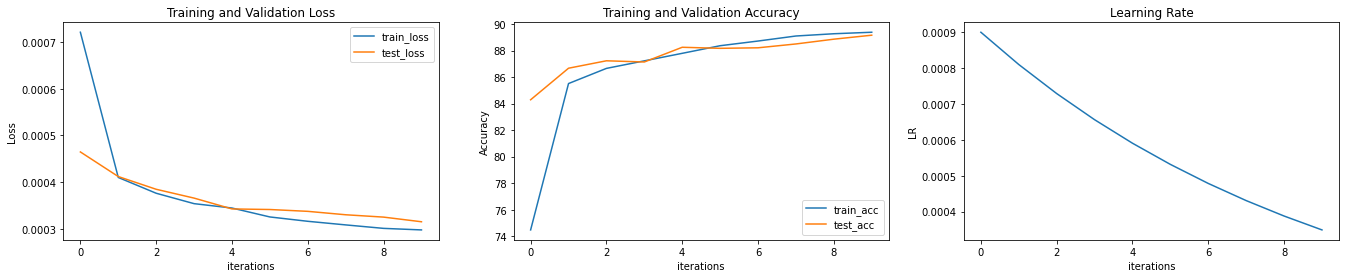

In [8]:
# early stopping, weight_decay, lr_scheduler
from torch.optim.lr_scheduler import ExponentialLR as ExponentialLR

EPOCHS = 10
best_loss = 1000 # 초기값 설정
patience = 0
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

model = Model().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001, weight_decay=0.01) # weight_decay - L1, L2 regularization
scheduler = ExponentialLR(optimizer, gamma=0.9) # lr 조정
criterion = nn.CrossEntropyLoss()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train(model, train_loader, optimizer, scheduler)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tLR: {:.4f}, \tTrain Loss: {:.4f}, \tTrain Accuracy: {:.2f} %, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, optimizer.param_groups[0]['lr'], train_loss, train_accuracy, test_loss, test_accuracy))

    # test_loss가 증가하는 시점에서 stop training
    if test_loss < best_loss:
        best_loss = test_loss
        patience = 0
    else:
        patience += 1
        if patience >= 5:
            break

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
plot_history(history)

In [14]:
# ----- Custom Learning Rate Scheduler -----

In [10]:
class ScheduledOptim():

    def __init__(self, optimizer, n_warmup_steps, decay_rate, steps=None):
        self._optimizer = optimizer
        self.n_warmup_steps = n_warmup_steps # 처음에 lr를 0부터 initial lr까지 몇 스텝동안 올릴 것인지
        self.decay = decay_rate # lr를 얼만큼의 비율로 줄여나갈 것인지
        self.n_steps = 0 # 현재 몇번째 epoch에 있는지
        self.steps = steps # lr decay를 매 epoch마다가 아니라 계단식으로 하고 싶은 경우
        self.initial_lr = optimizer.param_groups[0]['lr']
        self.current_lr = optimizer.param_groups[0]['lr']

    def zero_grad(self):
        self._optimizer.zero_grad()

    def step(self):
        self.update()
        # self._optimizer.step()
    
    def get_lr(self):
        return self.current_lr
    
    def update(self):
        if self.n_steps < self.n_warmup_steps:
            lr = (self.n_steps / self.n_warmup_steps) * self.initial_lr
        elif self.n_steps == self.n_warmup_steps:
            lr = self.initial_lr
        else:
            if self.steps is None:
                lr = self.current_lr * self.decay
            else:
                if self.n_steps in self.steps:
                    lr = self.current_lr * self.decay
                else:
                    lr = self.current_lr
        
        self.current_lr = lr
        
        for param_groups in self._optimizer.param_groups: # 실제로 optimizer에 적용
            param_groups['lr'] = lr

        self.n_steps += 1

In [ ]:
EPOCHS = 10
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

model = Model().to(DEVICE)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
#### TODO ####

##############

for epoch in range(1, EPOCHS + 1):
    lr = scheduler.get_lr()
    train_loss, train_accuracy = train(model, train_loader, optimizer, scheduler)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tLR: {:.5f}, \tTrain Loss: {:.4f}, \tTrain Accuracy: {:.2f} %, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, lr, train_loss, train_accuracy, test_loss, test_accuracy))
    
    #### TODO ####

    ##############

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_accuracy)
    history['lr'].append(lr)
    
plot_history(history)

# ----- Custom Learning Rate Scheduler -----

In [ ]:
class ScheduledOptim():

    def __init__(self, optimizer, n_warmup_steps, decay_rate, steps=None):
        self._optimizer = optimizer
        self.n_warmup_steps = n_warmup_steps
        self.decay = decay_rate
        self.n_steps = 0
        self.steps = steps
        self.initial_lr = optimizer.param_groups[0]['lr']
        self.current_lr = optimizer.param_groups[0]['lr']

    def zero_grad(self):
        self._optimizer.zero_grad()

    def step(self):
        self.update()
        # self._optimizer.step()
    
    def get_lr(self):
        return self.current_lr
    
    def update(self):
        #### TODO ####

        ##############

        self.n_steps += 1

In [ ]:
EPOCHS = 10
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

model = Model().to(DEVICE)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
#### TODO ####

##############

for epoch in range(1, EPOCHS + 1):
    lr = scheduler.get_lr()
    train_loss, train_accuracy = train(model, train_loader, optimizer, scheduler)
    test_loss, test_accuracy = evaluate(model, test_loader)
    print("\n[EPOCH: {}], \tLR: {:.5f}, \tTrain Loss: {:.4f}, \tTrain Accuracy: {:.2f} %, \tTest Loss: {:.4f}, \tTest Accuracy: {:.2f} % \n".format(
        epoch, lr, train_loss, train_accuracy, test_loss, test_accuracy))
    
    #### TODO ####

    ##############

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_accuracy)
    history['lr'].append(lr)
    
plot_history(history)

# RNN Text Classification

In [ ]:
train_data, test_data = torchtext.datasets.AG_NEWS(root='./data')
labels = [_, 'World', 'Sports', 'Business', 'Sci/Tech']
y, x = next(iter(train_data))
print(labels[y])
print(x)

In [ ]:
y, x = next(iter(test_data))
print(labels[y])
print(x)

In [ ]:
set([label for (label, text) in train_data]), set([label for (label, text) in test_data])

In [ ]:
from torchtext.data.utils import get_tokenizer

tokenizer = get_tokenizer('basic_english')
tokenizer("Hi, my name is Joonseok!")

In [ ]:
from torchtext.vocab import build_vocab_from_iterator

def tokens(data_iter):
    for _, text in data_iter:
        yield tokenizer(text)

encoder = build_vocab_from_iterator(tokens(train_data), specials=["<unk>"])
encoder.set_default_index(encoder["<unk>"])

encoder(tokenizer("Hi, my name is Joonseok <unk> !"))

In [ ]:
text_pipeline = lambda x: encoder(tokenizer(x))
label_pipeline = lambda x: int(x) - 1

In [ ]:
iterator = iter(train_data)
sample_batch = []
for _ in range(8):
    sample_batch.append(next(iterator))

In [ ]:
## What happens if we ignore zero-padding

def collate_batch(batch):
    label_list, text_list = [], []
    for (_label, _text) in batch:
        label_list.append(label_pipeline(_label))
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        text_list.append(processed_text)
    label_list = torch.tensor(label_list, dtype=torch.int64)
    text_list = torch.stack(text_list).long()
    return label_list, text_list

In [ ]:
collate_batch(sample_batch)

In [ ]:
MAX_LEN = 32

def collate_batch(batch):
    label_list, text_list = [], []
    for (_label, _text) in batch:
        label_list.append(label_pipeline(_label))
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        if processed_text.size(0) >= MAX_LEN:
            processed_text = processed_text[:MAX_LEN]
        else:
            processed_text = torch.cat([processed_text, 
                                  torch.zeros(MAX_LEN-processed_text.size(0))])
        text_list.append(processed_text)
    label_list = torch.tensor(label_list, dtype=torch.int64)
    text_list = torch.stack(text_list).long()
    return label_list, text_list

In [ ]:
collate_batch(sample_batch)

In [ ]:
dataloader = DataLoader(train_data, batch_size=8, shuffle=False, collate_fn=collate_batch)

y, x = next(iter(dataloader))
x.shape, y.shape

In [ ]:
num_class = len(set([label for (label, text) in train_data]))
vocab_size = len(encoder)
emsize = 64
hidden_dim = 32

embedding = nn.Embedding(vocab_size, emsize)
rnn = nn.RNN(emsize, hidden_dim, 1, nonlinearity='tanh', bias=True, batch_first=True)
fc = nn.Linear(hidden_dim, num_class)

In [ ]:
## Check the tensor shapes after each layer

init_h = torch.randn(1, 8, hidden_dim)
output, hidden = rnn(embedding(x), init_h)
# embedding(x).shape
# fc(output).shape

In [ ]:
class TextClassificationModel(nn.Module):

    def __init__(self, vocab_size, hidden, embed, num_class, batch_size):
        super(TextClassificationModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed)
        self.rnn = nn.RNN(input_size=embed, hidden_size=hidden, 
                          num_layers=1, nonlinearity='tanh', 
                          bias=True, batch_first=True)
        self.fc = nn.Linear(hidden, num_class)
        self.init_weights()

    def init_weights(self):
        initrange = 0.5
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.fc.weight.data.uniform_(-initrange, initrange)
        self.fc.bias.data.zero_()

    def forward(self, x):
        x = self.embedding(x)
        x, h = self.rnn(x)
        x = torch.mean(x, dim=1)
        return self.fc(x)

In [ ]:
import time

def train(dataloader):
    model.train()
    total_acc, total_count = 0, 0
    log_interval = 500
    start_time = time.time()

    for idx, (label, text) in enumerate(dataloader):
        label, text = label.to(DEVICE), text.to(DEVICE)
        optimizer.zero_grad()
        predicted_label = model(text)
        loss = criterion(predicted_label, label)
        loss.backward()
        optimizer.step()
        total_acc += (predicted_label.argmax(1) == label).sum().item()
        total_count += label.size(0)
        if idx % log_interval == 0 and idx > 0:
            elapsed = time.time() - start_time
            print('| epoch {:3d} | {:5d}/{:5d} batches '
                  '| accuracy {:8.3f}'.format(epoch, idx, len(dataloader),
                                              total_acc/total_count))
            total_acc, total_count = 0, 0
            start_time = time.time()

def evaluate(dataloader):
    model.eval()
    total_acc, total_count = 0, 0

    with torch.no_grad():
        for idx, (label, text) in enumerate(dataloader):
            label, text = label.to(DEVICE), text.to(DEVICE)
            predicted_label = model(text)
            loss = criterion(predicted_label, label)
            total_acc += (predicted_label.argmax(1) == label).sum().item()
            total_count += label.size(0)
    return total_acc/total_count

In [ ]:
from torchtext.data.functional import to_map_style_dataset

# Hyperparameter Setup

EPOCHS = 5
LR = 1
BATCH_SIZE = 64
num_class = len(set([label for (label, text) in train_data]))
vocab_size = len(encoder)
emsize = 64
hidden_dim = 32

model = TextClassificationModel(vocab_size, hidden_dim, emsize, num_class, BATCH_SIZE).to(DEVICE)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)
total_accu = None

train_dataset = to_map_style_dataset(train_data)
test_dataset = to_map_style_dataset(test_data)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              shuffle=True, collate_fn=collate_batch)
valid_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                              shuffle=True, collate_fn=collate_batch)

In [ ]:
## Train the RNN for text classification

for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()
    train(train_dataloader)
    accu_val = evaluate(valid_dataloader)
    if total_accu is not None and total_accu > accu_val:
      scheduler.step()
    else:
       total_accu = accu_val
    print('-' * 59)
    print('| end of epoch {:3d} | time: {:5.2f}s | '
          'valid accuracy {:8.3f} '.format(epoch,
                                           time.time() - epoch_start_time,
                                           accu_val))
    print('-' * 59)